In [40]:
import pandas as pd
import seaborn as sns
import label
from metadata import get_json
from ripser import Rips
from persim import wasserstein
from sklearn.manifold import MDS, TSNE
from gudhi.representations import PersistenceScaleSpaceKernel
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
muscles = get_json("muscles")

In [5]:
dataloader = label.DataLoader()

In [6]:
data = dataloader.get_data().reset_index(level=1, drop=True)[[*muscles, "Prescribed Sub-Task"]]

In [7]:
joint = [g for g in data.groupby("Trial")]

In [8]:
trials = [g[0] for g in joint]

In [9]:
def take_until_change(group):
    partition = []
    curr = []
    for i in range(len(group) - 1):
        if group[i][-1] != group[i + 1][-1]:
            curr.append(i)
            partition.append(curr)
            curr = []
        else:
            curr.append(i)
    min_len_rep = min([len(p) for p in partition])
    return group[[p[:min_len_rep] for p in partition]]

In [10]:
data_and_labels = [take_until_change(g[1].reset_index(drop=True).values) for g in joint]

In [11]:
data = [g[:, :, :-1] for g in data_and_labels]
sub_task_labels = [g[:, :, -1] for g in data_and_labels]

In [12]:
labels = [(trial.subject, trial.condition, trial.activity, int(sub_task_labels[i][j].sum() / len(sub_task_labels[i][j])), i, j) for i, trial in enumerate(trials) for j in range(len(sub_task_labels[i]))]

In [13]:
def takens_indices(tau, d, n_samples):
    def _takens_indices(t):
        return [t + n * tau for n in range(d + 1)]
    return list(filter(lambda x: x[-1] < n_samples, map(_takens_indices, range(n_samples))))

def trial_to_takens_embeddings(trial, data, tau, d, sample_rate=20):
    embedding = data[takens_indices(tau=tau, d=d, n_samples=data.shape[0])]
    embedding = embedding.reshape(embedding.shape[0], -1)
    return (trial, embedding[::sample_rate])

In [15]:
#%%capture

trials_takens_embeddings = dict([trial_to_takens_embeddings(label, data[label[-2]][label[-1]], 50, 10, sample_rate=100) for label in labels])

trials_ripsers = dict([(label, Rips().fit_transform(trials_takens_embeddings[label])) for label in labels])

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbos

/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  w

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbos

/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  w

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbos

...

/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  w

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbos

/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  w

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)
Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbos

/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/usr/local/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  w

In [19]:
import csv

In [21]:
for t, h in list(trials_ripsers.items()):
    with open(f"ripsers/reps/{t[0]}-{t[1]}-{t[2]}-{t[3]}-{t[5]}.csv", "w", newline="\n") as file:
        writer = csv.writer(file)
        writer.writerow(["s", "c", "a", "p", "r", "h", "0", "1"])
        for i in range(len(h)):
            for j in range(len(h[i])):
                writer.writerow([t[0], t[1], t[2], t[3], t[5], i, h[i][j][0], h[i][j][1]])

In [66]:
%%capture

stacked_rips_h0 = [rips[0] for rips in trials_ripsers.values()]

pairwise_distances = np.zeros((len(stacked_rips_h0), len(stacked_rips_h0)))

precomputed_indices = []
for i in range(len(stacked_rips_h0)):
    for j in range(i, len(stacked_rips_h0)):
        if i == j:
            continue
        else:
            precomputed_indices.append((i, j))

for i, j in precomputed_indices:
    if pairwise_distances[i, j] != 0:
        continue
    d = wasserstein(stacked_rips_h0[i], stacked_rips_h0[j])
    pairwise_distances[i, j] = d
pairwise_distances = pairwise_distances + pairwise_distances.T

tsne = TSNE(n_components=2, metric="precomputed", init="random").fit_transform(pairwise_distances)

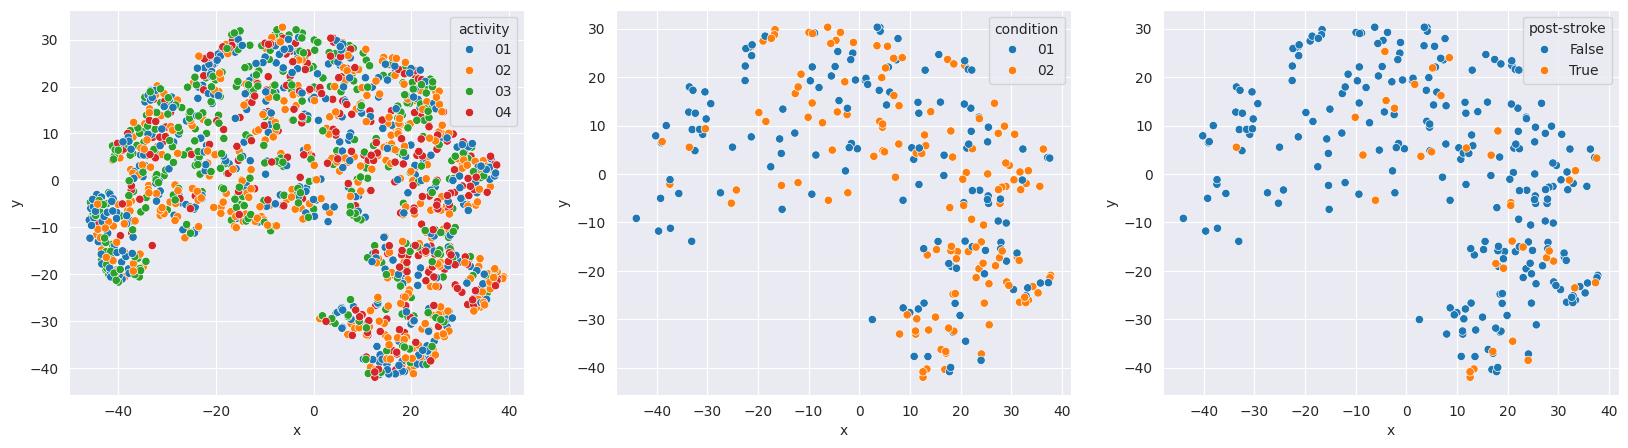

In [67]:
pd.DataFrame(pairwise_distances).to_csv(f"./pairwise-distances/reps/pairwise-h0.csv", index=False)

tsne_df = pd.DataFrame(tsne, columns=["x", "y"])
tsne_df["post-stroke"] = [label[0] == "21" or label[0] == "22" for label in labels]
tsne_df["condition"] = [label[1] for label in labels]
tsne_df["activity"] = [label[2] for label in labels]
tsne_df["sub_task"] = [label[3] for label in labels]
tsne_df["participant"] = [label[0] for label in labels]

tsne_df.to_csv("tsne-0-reps.csv", index=False)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(tsne_df, x="x", y="y", hue="activity", ax=axs[0]);
sns.scatterplot(tsne_df[tsne_df["activity"] == "04"], x="x", y="y", hue="condition", ax=axs[1]);
sns.scatterplot(tsne_df[tsne_df["activity"] == "04"], x="x", y="y", hue="post-stroke", ax=axs[2]);
plt.savefig(f"./figures/reps/tsne-h0.pdf")

In [48]:
%%capture
stacked_rips_h1 = [rips[1] for rips in trials_ripsers.values()]

pairwise_distances_h1 = np.zeros((len(stacked_rips_h1), len(stacked_rips_h1)))

precomputed_indices = []
for i in range(len(stacked_rips_h1)):
    for j in range(i, len(stacked_rips_h1)):
        if i == j:
            continue
        else:
            precomputed_indices.append((i, j))

for i, j in tqdm(precomputed_indices):
    d = wasserstein(stacked_rips_h1[i], stacked_rips_h1[j])
    pairwise_distances_h1[i, j] = d
pairwise_distances_h1 = pairwise_distances_h1 + pairwise_distances_h1.T

tsne = TSNE(n_components=2, metric="precomputed", init="random").fit_transform(pairwise_distances_h1)


100%|██████████| 1036080/1036080 [06:53<00:00, 2507.01it/s]


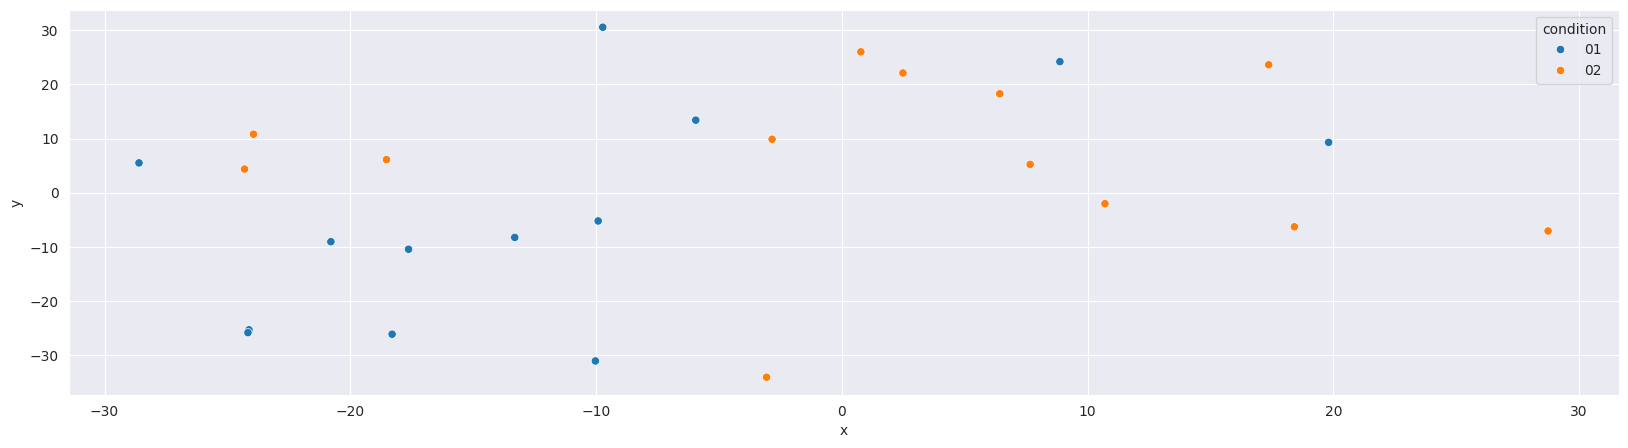

In [63]:
pd.DataFrame(pairwise_distances).to_csv(f"./pairwise-distances/reps/pairwise-h1.csv", index=False)

tsne_df = pd.DataFrame(tsne, columns=["x", "y"])
tsne_df["post-stroke"] = [label[0] == "21" or label[0] == "22" for label in labels]
tsne_df["condition"] = [label[1] for label in labels]
tsne_df["activity"] = [label[2] for label in labels]
tsne_df["sub_task"] = [label[3] for label in labels]
tsne_df["participant"] = [label[0] for label in labels]

#tsne_df.to_csv("tsne-1-reps.csv", index=False)

fig, axs = plt.subplots(1, 1, figsize=(20, 5))
sns.scatterplot(tsne_df[(tsne_df["activity"] == "01") & (tsne_df["participant"] == "08")], x="x", y="y", hue="condition", ax=axs);
plt.savefig(f"./figures/reps/tsne-h1.pdf")